# 05. Événements pivot

Ce notebook analyse l’impact des **événements pivot** — moments clés comme les décisions du CIJ, l’offensive de Rafah ou les mandats CPI — sur le positionnement discursif. On mobilise le **corpus par fenêtres événementielles** : chaque **batch** désigne une fenêtre temporelle centrée sur un événement, afin d’isoler les discours produits au plus près de l’événement. On examine les **variables batch-spécifiques** (moyenne et variance du positionnement par batch et par bloc), l’appel au cessez-le-feu, la conditionnalité du discours, et une **régression avec interaction** bloc × batch pour tester si l’effet des événements varie selon la famille politique.

## Setup et configuration

Les bibliothèques et les deux versions du corpus, principal et par fenêtres événementielles, sont chargés.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, BATCH_ORDER, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## Chargement du corpus

Le corpus principal et le corpus par fenêtres événementielles (batches) sont chargés pour l’analyse des effets événementiels.

In [2]:
from config import CORPUS_V3, CORPUS_V4
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))

df_v4 = pd.read_parquet(CORPUS_V4)
df_v4['date'] = pd.to_datetime(df_v4['date'])
df_v4['month'] = df_v4['date'].dt.to_period('M').astype(str)

print(f"Corpus principal : {len(df):,} textes. Corpus par fenêtres événementielles : {len(df_v4):,} textes.")

Corpus principal : 10,774 textes. Corpus par fenêtres événementielles : 5,905 textes.


## Fig 28 : Variables par batch

Les variables batch-spécifiques résument le positionnement moyen et sa variance pour chaque combinaison bloc × batch. Le graphique permet de visualiser les inflexions liées aux événements pivot selon la famille politique.

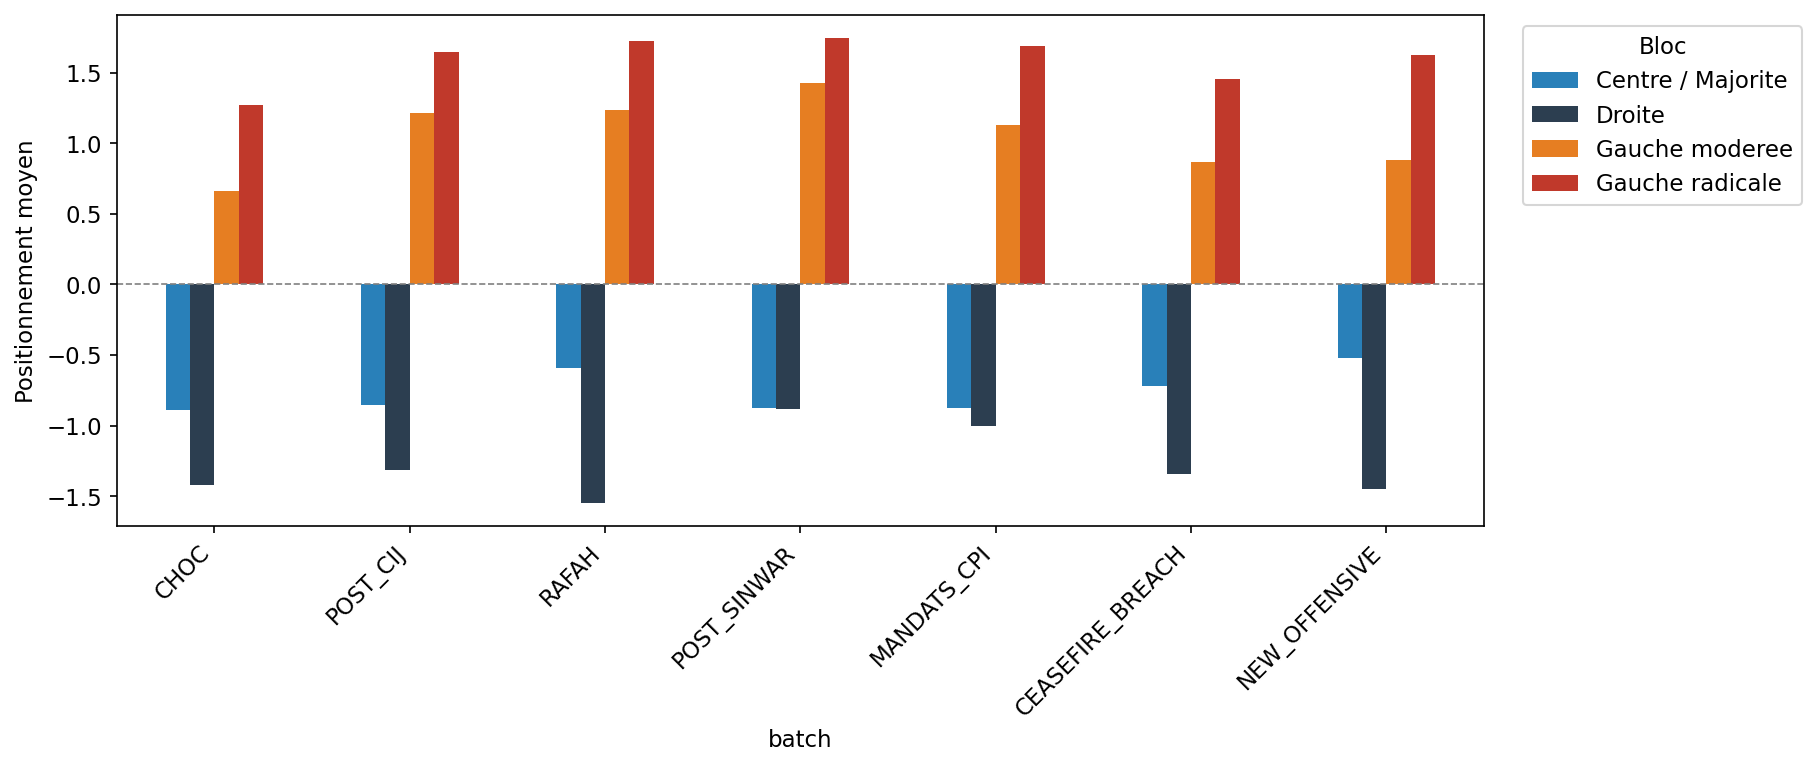

In [3]:
batch_col = 'batch' if 'batch' in df_v4.columns else None
if batch_col:
    var_batch = df_v4.groupby('batch').agg(
        n=('stance_v3', 'count'),
        stance_mean=('stance_v3', 'mean'),
        stance_std=('stance_v3', 'std')
    ).reindex(BATCH_ORDER).dropna(how='all')
    var_batch.to_csv(RES_DIR / 'variables_batch_specifiques.csv')
    batches = [b for b in BATCH_ORDER if b in df_v4['batch'].values]
else:
    batches = []

if len(batches) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    stance_by_batch = df_v4[df_v4['batch'].isin(batches)].groupby(['batch', 'bloc'])['stance_v3'].mean().unstack(fill_value=np.nan)
    stance_by_batch = stance_by_batch.reindex(batches)
    stance_by_batch.plot(kind='bar', ax=ax, color=[BLOC_COLORS.get(b, '#888') for b in stance_by_batch.columns])
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    ax.set_ylabel('Positionnement moyen')
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Bloc', bbox_to_anchor=(1.02, 1))
    save('fig28_variables_batch')
else:
    stance_m = df.groupby(['month', 'bloc'])['stance_v3'].mean().unstack(fill_value=np.nan).reindex(columns=BLOC_ORDER)
    fig, ax = plt.subplots(figsize=(12, 5))
    stance_m.plot(ax=ax, color=[BLOC_COLORS.get(b, '#888') for b in BLOC_ORDER])
    ax.axhline(0, color='grey', ls='--', lw=0.8)
    save('fig28_variables_batch')

Le positionnement varie nettement selon le batch ; les événements juridiques (CIJ, CPI) et le cessez-le-feu marquent des inflexions dans le discours du Centre.

## Fig 29 : Cessez-le-feu par batch et bloc

La part de textes contenant un appel explicite au cessez-le-feu est calculée par batch (fenêtre événementielle) et par bloc, à partir du corpus par fenêtres événementielles.

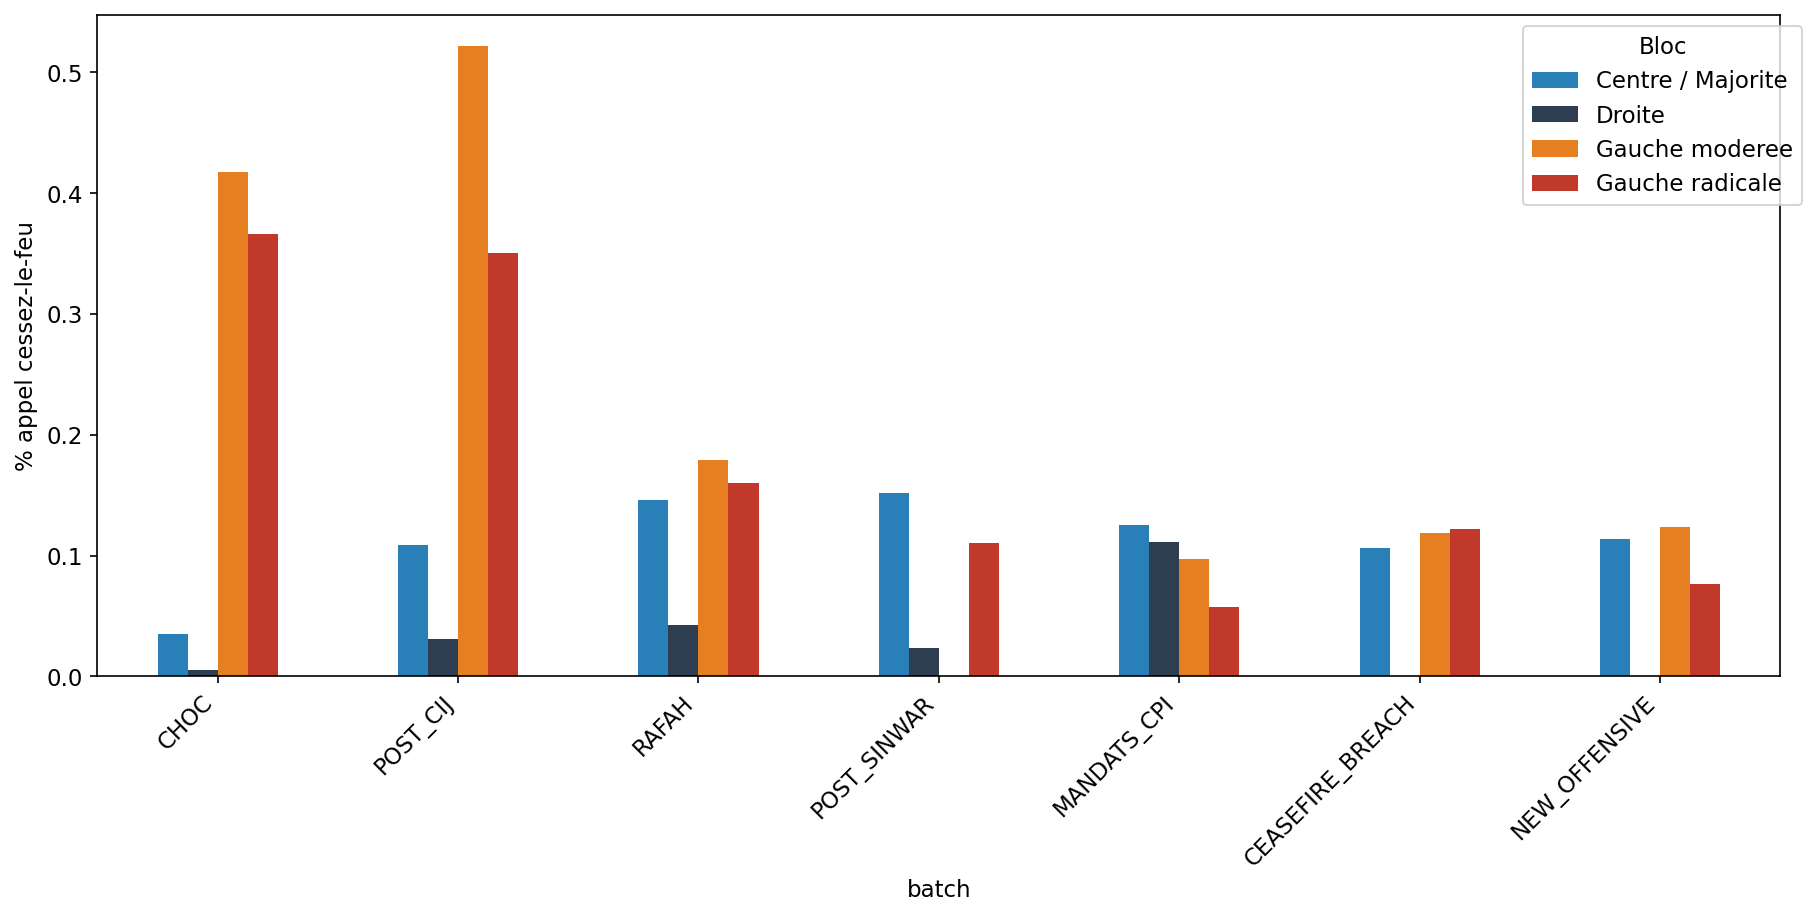

In [4]:
if 'ceasefire_call' in df_v4.columns and batch_col:
    cf = df_v4.groupby(['batch', 'bloc']).agg(pct=('ceasefire_call', 'mean'), n=('ceasefire_call', 'count')).reset_index()
    cf.to_csv(RES_DIR / 'ceasefire_call_batch_bloc.csv', index=False)
    piv = cf.pivot(index='batch', columns='bloc', values='pct').reindex([b for b in BATCH_ORDER if b in cf['batch'].values])
    fig, ax = plt.subplots(figsize=(12, 6))
    piv.plot(kind='bar', ax=ax, color=[BLOC_COLORS.get(b, '#888') for b in piv.columns])
    ax.set_ylabel('% appel cessez-le-feu')
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Bloc', bbox_to_anchor=(1.02, 1))
    save('fig29_ceasefire_call_batch')
else:
    tc = 'text_clean' if 'text_clean' in df.columns else 'text'
    df['_cf'] = df[tc].astype(str).str.contains(r'cessez|ceasefire|tr[êe]ve', case=False, na=False)
    cf_lex = df.groupby(['month', 'bloc'])['_cf'].mean().reset_index()
    cf_lex = cf_lex.rename(columns={'_cf': 'pct'})
    cf_lex['month_ts'] = pd.to_datetime(cf_lex['month'] + '-01')
    fig, ax = plt.subplots(figsize=(12, 5))
    for bloc in BLOC_ORDER:
        sub = cf_lex[cf_lex['bloc'] == bloc]
        if len(sub) > 0:
            ax.plot(sub['month_ts'], sub['pct']*100, label=bloc, color=BLOC_COLORS.get(bloc, '#888'))
    ax.legend()
    ax.set_ylabel('% lexique cessez-le-feu')
    save('fig29_ceasefire_call_batch')

L’appel explicite au cessez-le-feu chute à gauche après Sinwar et augmente au Centre après Rafah et les mandats CPI.

## Fig 30 : Conditionnalité

La conditionnalité désigne les modalités de l’appel au cessez-le-feu : humanitaire, inconditionnel, conditionnel, etc. On observe la répartition de ces types par bloc parmi les textes qui appellent au cessez-le-feu.

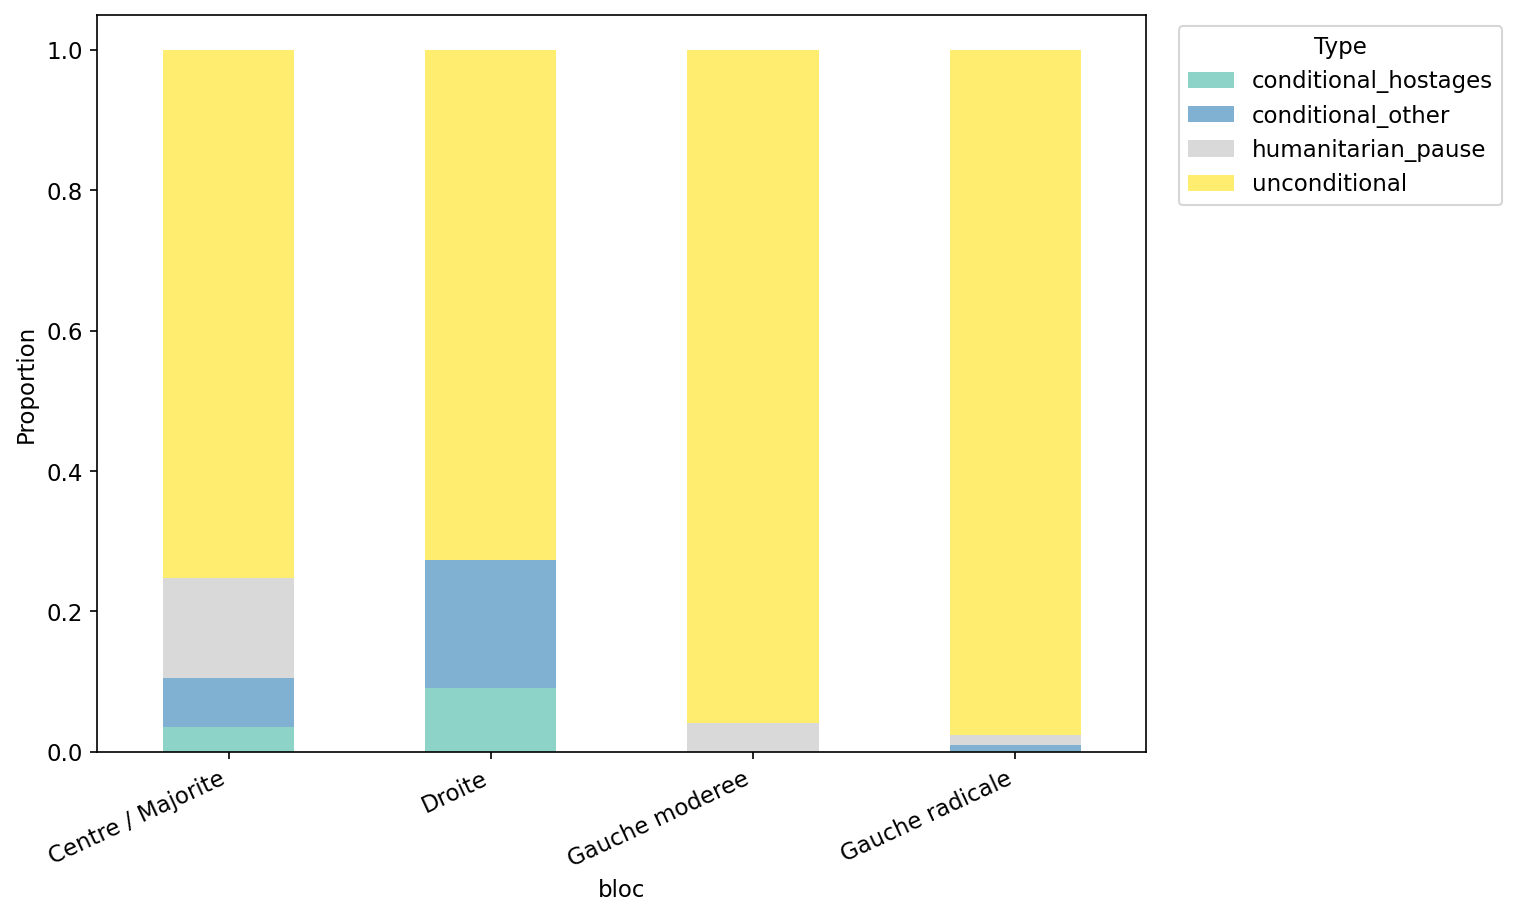

In [5]:
cond_col = 'ceasefire_type' if 'ceasefire_type' in df_v4.columns else None
if cond_col:
    cond = df_v4[df_v4['ceasefire_call'] == True].groupby(['bloc', cond_col]).size().unstack(fill_value=0)
    cond_pct = cond.div(cond.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(10, 6))
    cond_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
    ax.set_ylabel('Proportion')
    plt.xticks(rotation=25, ha='right')
    ax.legend(title='Type', bbox_to_anchor=(1.02, 1))
    save('fig30_conditionnalite')
else:
    cond = df_v4.groupby('bloc')['stance_v3'].mean().reindex(BLOC_ORDER)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(cond.index, cond.values, color=[BLOC_COLORS.get(b, '#888') for b in cond.index])
    save('fig30_conditionnalite')

La conditionnalité du cessez-le-feu (humanitaire, inconditionnel, etc.) varie selon le bloc ; le Centre privilégie des formulations plus nuancées.

## Fig 31 : Régression avec interaction bloc × batch

La régression avec interaction bloc × batch teste si l’effet du batch (événement) sur le positionnement diffère selon le bloc politique. Un terme d’interaction significatif indique que certains blocs réagissent plus fortement aux événements que d’autres.

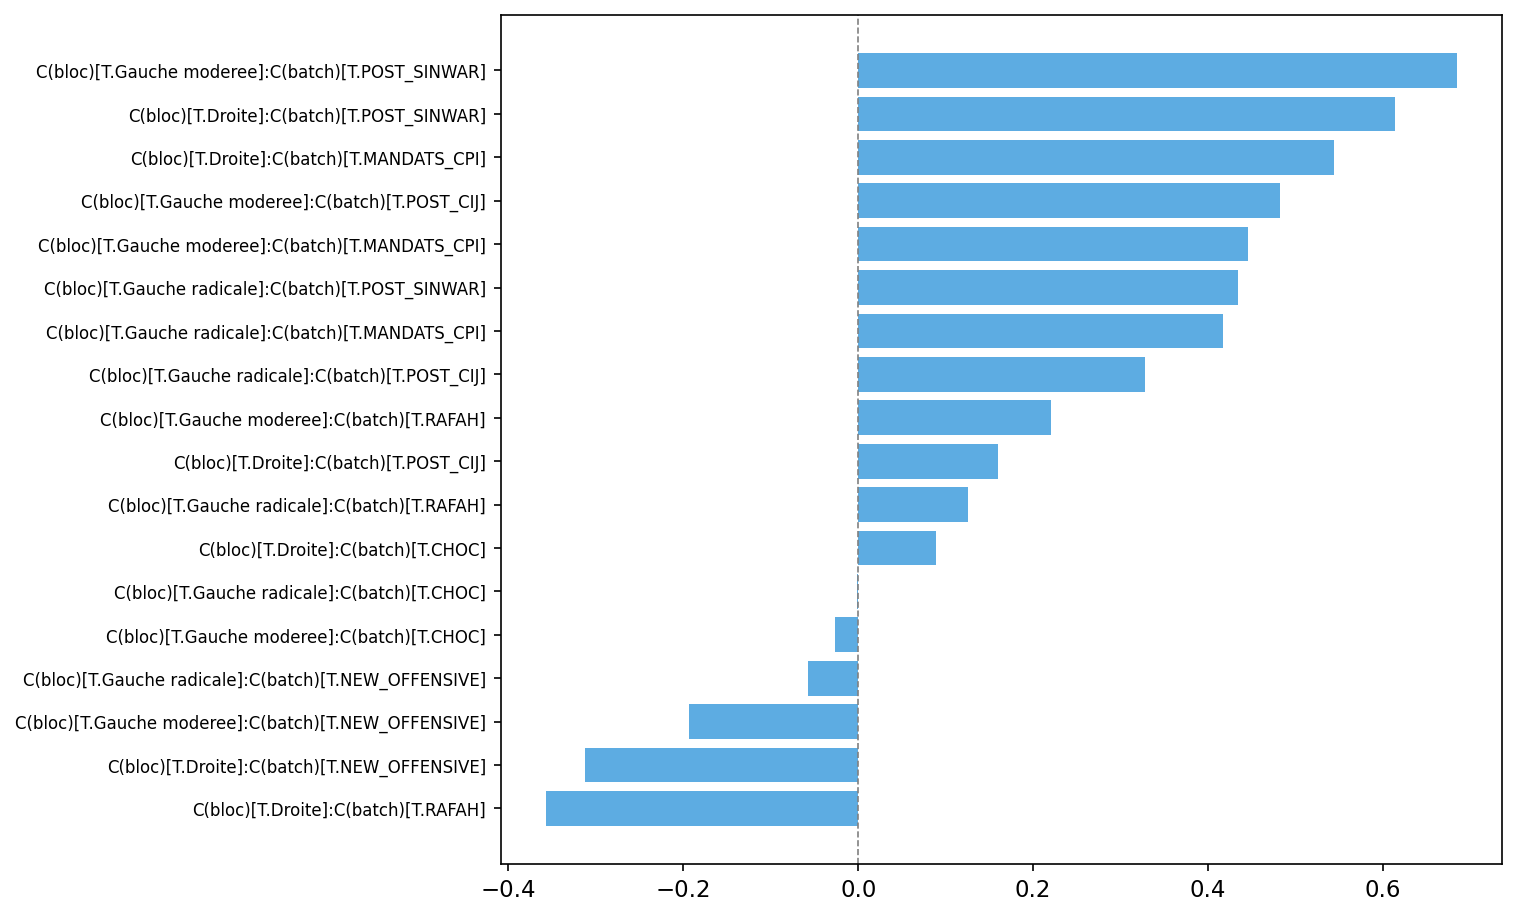

In [6]:
cols = ['stance_v3', 'bloc', 'arena'] + (['batch'] if 'batch' in df_v4.columns else [])
reg_df = df_v4[[c for c in cols if c in df_v4.columns]].dropna().copy()
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
if 'batch' in reg_df.columns:
    formula = 'stance_v3 ~ C(bloc) + C(batch) + C(arena) + C(bloc):C(batch)'
else:
    formula = 'stance_v3 ~ C(bloc) + C(arena)'
model = ols(formula, data=reg_df).fit()
anova_tab = anova_lm(model, typ=2)
anova_tab.to_csv(RES_DIR / 'anova_interaction.csv')
coef = model.params
fig, ax = plt.subplots(figsize=(10, 6))
interaction_terms = [c for c in coef.index if ':' in str(c)]
if len(interaction_terms) > 0:
    sel = coef.loc[interaction_terms].sort_values()
    ax.barh(range(len(sel)), sel.values, color='#3498db', alpha=0.8)
    ax.set_yticks(range(len(sel)))
    ax.set_yticklabels(sel.index, fontsize=8)
else:
    bloc_coefs = [c for c in coef.index if 'bloc' in str(c)]
    ax.barh(range(len(bloc_coefs)), coef[bloc_coefs].values, color='#3498db', alpha=0.8)
    ax.set_yticks(range(len(bloc_coefs)))
    ax.set_yticklabels(bloc_coefs, fontsize=8)
ax.axvline(0, color='grey', ls='--', lw=0.8)
save('fig31_regression_interaction')

L’interaction bloc × batch est significative : l’effet des événements sur le positionnement diffère selon le bloc politique.

## Fig 32 : ANOVA Type II

L’ANOVA de type II décompose la variance du positionnement entre les facteurs (bloc, batch, arène) et leurs interactions. Elle permet d’évaluer la contribution relative de chaque facteur à l’explication de la variance.

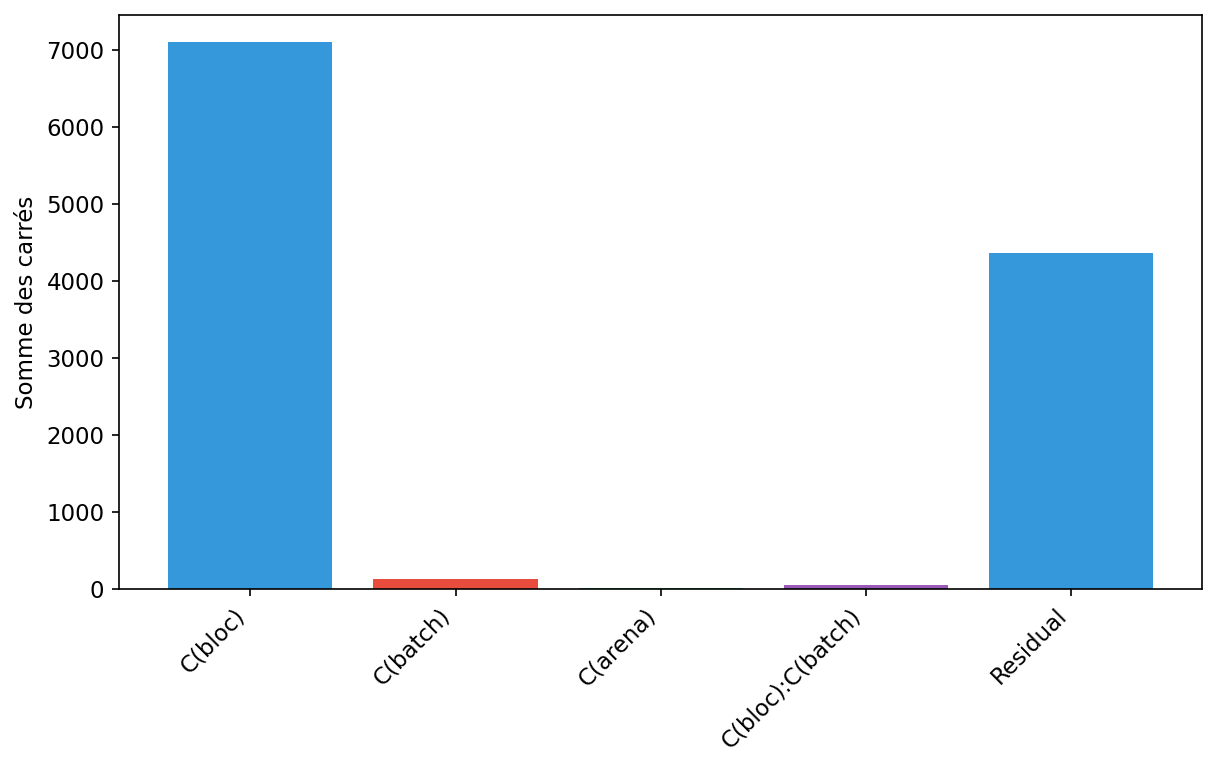

In [7]:
# Merge v3/v4 pour récupérer stance_v3 si absent du corpus événementiel
merge_key = next((c for c in ['text_hash', 'text_id'] if c in df.columns and c in df_v4.columns), None)
df_reg = df_v4 if 'stance_v3' in df_v4.columns else (df.merge(df_v4[[merge_key, 'batch']].drop_duplicates(), on=merge_key, how='inner') if merge_key else df_v4)
if 'batch' in df_reg.columns:
    reg_df = df_reg[['stance_v3', 'bloc', 'batch', 'arena']].dropna()
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    model = ols('stance_v3 ~ C(bloc) + C(batch) + C(arena) + C(bloc):C(batch)', data=reg_df).fit()
    anova_tab = anova_lm(model, typ=2)
    anova_tab = anova_tab.reset_index()
    anova_tab.to_csv(RES_DIR / 'anova_type2.csv', index=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(anova_tab['index'], anova_tab['sum_sq'], color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'][:len(anova_tab)])
    ax.set_ylabel('Somme des carrés')
    plt.xticks(rotation=45, ha='right')
    save('fig32_anova')
else:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    reg_df = df_reg[['stance_v3', 'bloc', 'arena']].dropna()
    model = ols('stance_v3 ~ C(bloc) + C(arena)', data=reg_df).fit()
    anova_tab = anova_lm(model, typ=2).reset_index()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(anova_tab['index'], anova_tab['sum_sq'], color='#3498db', alpha=0.8)
    plt.xticks(rotation=25, ha='right')
    save('fig32_anova')

Le bloc politique explique la plus grande part de la variance du positionnement ; le batch et l’interaction apportent des contributions significatives.